In [1]:
import numpy as np
import matplotlib.pyplot as plt
import keras
from IQT import *

import IQT.util

import tensorflow as tf

2024-02-01 14:30:39.822561: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-02-01 14:30:39.851415: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-02-01 14:30:39.851490: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-02-01 14:30:39.852453: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-02-01 14:30:39.857440: I tensorflow/core/platform/cpu_feature_guar

In [3]:
test_data = data_loader.DataLoader(data_dir="../data",
                                   subject_labels=['100307'],
                                   subdir='LR',
                                   file_head='dt_b1000_lowres_2_',
                                   # file_head='dt_b1000_',
                                   normalization_method='stdscore',
                                   mode='dti')

In [4]:
target_data = IQT.util.load_dtis("../data/100307/HR/", "dt_b1000_")

In [5]:
target_tensors = target_data[..., 2:]

norm_metrics_target = IQT.util.apply_normalization(target_tensors, target_data[..., 0]==0, 'stdscore')

target_tensors.shape

(145, 174, 145, 6)

In [6]:
run_indices = test_data.get_grid_indices(0, 7, 7)

run_indices

[(8, 8, 8),
 (23, 8, 8),
 (38, 8, 8),
 (53, 8, 8),
 (68, 8, 8),
 (83, 8, 8),
 (98, 8, 8),
 (113, 8, 8),
 (128, 8, 8),
 (8, 23, 8),
 (23, 23, 8),
 (38, 23, 8),
 (53, 23, 8),
 (68, 23, 8),
 (83, 23, 8),
 (98, 23, 8),
 (113, 23, 8),
 (128, 23, 8),
 (8, 38, 8),
 (23, 38, 8),
 (38, 38, 8),
 (53, 38, 8),
 (68, 38, 8),
 (83, 38, 8),
 (98, 38, 8),
 (113, 38, 8),
 (128, 38, 8),
 (8, 53, 8),
 (23, 53, 8),
 (38, 53, 8),
 (53, 53, 8),
 (68, 53, 8),
 (83, 53, 8),
 (98, 53, 8),
 (113, 53, 8),
 (128, 53, 8),
 (8, 68, 8),
 (23, 68, 8),
 (38, 68, 8),
 (53, 68, 8),
 (68, 68, 8),
 (83, 68, 8),
 (98, 68, 8),
 (113, 68, 8),
 (128, 68, 8),
 (8, 83, 8),
 (23, 83, 8),
 (38, 83, 8),
 (53, 83, 8),
 (68, 83, 8),
 (83, 83, 8),
 (98, 83, 8),
 (113, 83, 8),
 (128, 83, 8),
 (8, 98, 8),
 (23, 98, 8),
 (38, 98, 8),
 (53, 98, 8),
 (68, 98, 8),
 (83, 98, 8),
 (98, 98, 8),
 (113, 98, 8),
 (128, 98, 8),
 (8, 113, 8),
 (23, 113, 8),
 (38, 113, 8),
 (53, 113, 8),
 (68, 113, 8),
 (83, 113, 8),
 (98, 113, 8),
 (113, 113, 8),


In [7]:
test_data.shape(0)

(145, 174, 145)

In [8]:
recon_model = np.zeros(test_data.shape(0)+ (6,))

recon_model.shape

(145, 174, 145, 6)

In [9]:
for (i, j, k) in run_indices:
    
    recon_model[i-7:i+8,
                j-7:j+8,
                k-7:k+8] = test_data.get_patch(0, [i, j, k], 15).numpy()
    

2024-02-01 14:32:00.457385: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-02-01 14:32:00.479810: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-02-01 14:32:00.479847: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-02-01 14:32:00.484970: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-02-01 14:32:00.485124: I external/local_xla/xla/stream_executor

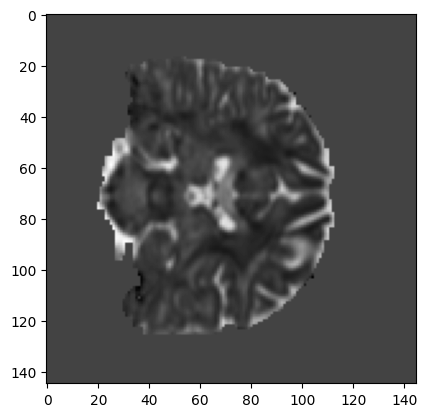

In [10]:
plt.imshow(recon_model[:, 80, :, 0], cmap='gray')

In [11]:
# model: keras.Model = models.simple_generator(input_ch=6, output_ch=6, layer_num=1, ipatch_size=11)
model: keras.Model = models.vdsr((145, 174, 145))

model.load_weights(filepath="../output/Run27")

In [12]:
model_output = np.zeros(test_data.shape(0)+ (6,))

model_output = model(recon_model[None,...])[0,...].numpy()

# for (i, j, k) in run_indices:
#     
#     model_output[i-15:i+16,
#                  j-15:j+16,
#                  k-15:k+16] = model(test_data.get_patch(0, [i, j, k], 31)[None,...]).numpy()

2024-02-01 14:32:01.887012: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8907
2024-02-01 14:32:02.027719: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2024-02-01 14:32:03.916903: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2024-02-01 14:32:03.993799: W external/local_tsl/tsl/framework/bfc_allocator.cc:296] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.63GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2024-02-01 14:32:04.289705: W external/local_tsl/tsl/framework/bfc_allocator.cc:296] Allocator (GPU_0_bfc) ran out of memory trying to allocate 3.50GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance 

In [13]:
model_output.shape

(145, 174, 145, 6)

In [14]:
model_output[target_data[..., 0] != 0, :] = 0
recon_model[target_data[...,0] != 0, :] = 0
target_tensors[target_data[...,0] != 0, :] = 0

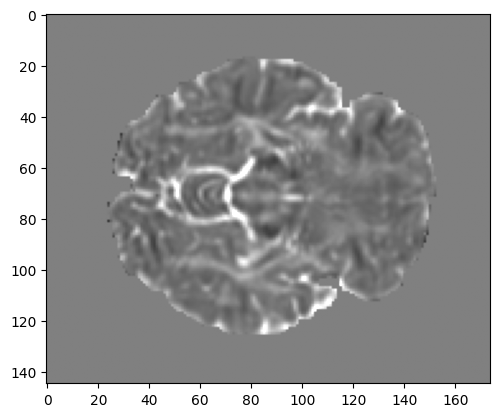

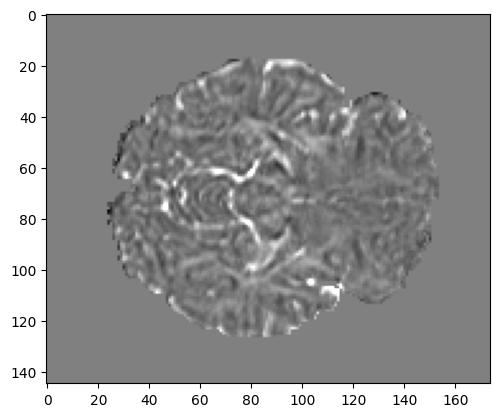

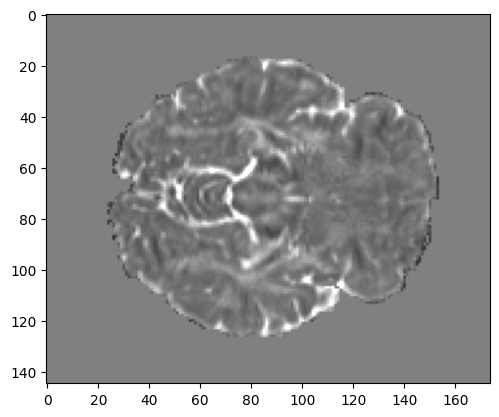

In [19]:
plt.imshow(recon_model[:, :, 50, 3], cmap='gray', vmin=-3, vmax=3)
plt.show()
plt.imshow(model_output[:, :, 50, 3], cmap='gray', vmin=-3, vmax=3)
plt.show()
plt.imshow(target_tensors[:, :, 50, 3], cmap='gray', vmin=-3, vmax=3)
plt.show()

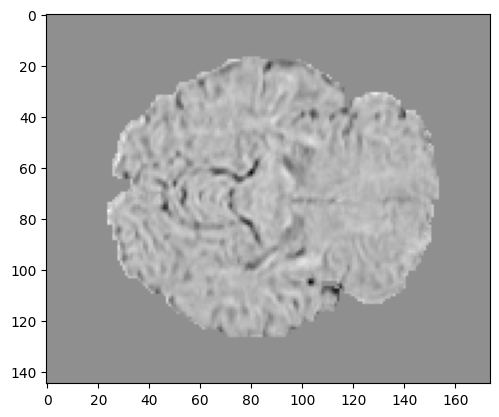

In [16]:
plt.imshow(target_data[:, :, 50, 0] - model_output[:, :, 50, 0], cmap='gray')

# print(np.mean(np.square(target_data[:, :, 60, 0] - model_output[:, :, 60, 0])))